In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 50)

df = pd.read_excel("[22_9] COMM5000-Used_Car_Price_Prediction.xlsm", sheet_name="DATA")

In [2]:
df.shape

(1005000, 20)

In [3]:
df.head(10)

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Car_Price
0,Toyota,Camry,2001,19.615852,1396.560379,NaN,Hybrid,Automatic,First,Grey,Chennai,500928,1,1,0,1,4,5,24,3.531896e+05
1,Hyundai,i20,2012,19.478608,1130.771005,137.021719,Petrol,Unknown,First,Grey,Mumbai,211510,0,1,0,1,4,5,13,9.596943e+05
2,Mahindra,Bolero,2008,17.469920,1766.466250,142.902960,Unknown,Automatic,First,Black,Kolkata,333999,1,0,0,1,5,5,17,2.920229e+05
3,BMW,X1,2015,21.295421,NaN,49.782079,Unknown,Manual,First,White,Pune,225930,1,1,3,1,4,5,10,2.949453e+06
4,Honda,Civic,2022,18.326833,1239.334935,121.505993,Diesel,Manual,Second,White,Kolkata,43404,1,0,0,1,5,5,3,6.365208e+05
5,Toyota,Camry,2007,NaN,1513.157430,100.927306,Petrol,Automatic,Second,Unknown,Unknown,321426,0,0,1,1,4,2,18,5.195264e+05
6,Hyundai,i20,2014,16.328654,1398.722600,111.846497,Diesel,Manual,First,Unknown,Chennai,200343,1,0,0,1,4,4,11,4.953191e+05
7,Hyundai,Creta,2001,21.895120,800.000000,0.709766,Petrol,Manual,Second,White,Kolkata,228720,1,0,0,1,5,5,24,5.000000e+04
8,Volkswagen,Taigun,2020,17.461847,1397.891768,104.095168,Diesel,Automatic,Fourth+,Black,Hyderabad,122025,1,1,0,1,4,5,5,1.045347e+06
9,Audi,A4,2009,12.062221,1618.723936,86.071024,Petrol,Manual,Second,Blue,Pune,395200,1,1,1,1,5,7,16,2.633309e+05


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1005000 entries, 0 to 1004999
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Brand             1005000 non-null  str    
 1   Model             1005000 non-null  str    
 2   Year              1005000 non-null  int64  
 3   Mileage_kmpl      924610 non-null   float64
 4   Engine_CC         924597 non-null   float64
 5   Horsepower        924597 non-null   float64
 6   Fuel_Type         1005000 non-null  str    
 7   Transmission      1005000 non-null  str    
 8   Owner_Type        1005000 non-null  str    
 9   Color             1005000 non-null  str    
 10  City              1005000 non-null  str    
 11  Kms_Driven        1005000 non-null  int64  
 12  Insurance_Valid   1005000 non-null  int64  
 13  Service_History   1005000 non-null  int64  
 14  Accidents         1005000 non-null  int64  
 15  Tax_Paid          1005000 non-null  int64  
 16  Number_of_D

- 1,005,000 dòng × 20 cột (19 biến + target `Car_Price`). Không có cột ID → giả định 1 dòng = 1 listing.
- 7 cột chữ (str), 13 cột số (int64 / float64) → kiểu dữ liệu hợp lý, không có cột số bị đọc thành chữ.
- `info()`: chỉ Mileage_kmpl (924,610), Engine_CC và Horsepower (924,597) có Non-Null < 1,005,000 → có missing.
- `head(10)`: thấy ngay NaN, 'Unknown' (Fuel_Type, Transmission, Color, City) và 1 xe có Engine_CC = 800, Car_Price = 50,000 → cần kiểm tra các giá trị tròn này.

In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Year,1005000.0,2012.00,7.21,2000.00,2006.00,2012.00,2018.00,2024.00
Mileage_kmpl,924610.0,18.00,3.99,5.00,15.30,18.00,20.69,36.28
Engine_CC,924597.0,1506.63,386.03,800.00,1230.41,1500.18,1769.60,3362.02
Horsepower,924597.0,120.57,36.78,-18.51,94.84,120.05,145.48,290.25
Kms_Driven,1005000.0,202863.89,175370.54,5000.00,84555.00,166313.00,286380.00,4368000.00
Insurance_Valid,1005000.0,0.85,0.36,0.00,1.00,1.00,1.00,1.00
Service_History,1005000.0,0.75,0.43,0.00,1.00,1.00,1.00,1.00
Accidents,1005000.0,0.30,0.55,0.00,0.00,0.00,1.00,5.00
Tax_Paid,1005000.0,0.90,0.30,0.00,1.00,1.00,1.00,1.00
Number_of_Doors,1005000.0,4.25,0.70,2.00,4.00,4.00,5.00,5.00


**Observations**
- `count`: Mileage_kmpl, Engine_CC, Horsepower còn khoảng 924.6k / 1,005k dòng → thiếu khoảng 8%, check ở bước missing.
- `Horsepower` min = -18.51 → giá trị âm, không hợp lệ. Cần đếm số dòng.
- `Kms_Driven`: P75 = 286k nhưng max = 4.37M (≈ 15× P75) → nghi outlier/implausible.
- `Car_Price`: mean 1.01M > median 759k (chênh +33%) → right-skewed, dùng median khi báo cáo.
- Min của `Car_Price` (50,000), `Engine_CC` (800), `Mileage_kmpl` (5) đều là số tròn → nghi bị chặn sàn, cần đếm tần suất tại min.
- `Year` 2000–2024 và `Registration_Age` 1–25 → có thể trùng thông tin, check `Year + Registration_Age`.
- Các biến binary và discrete (Insurance, Service, Tax, Doors, Seats, Accidents) nằm trong khoảng hợp lý.

**To do:** đếm HP ≤ 0; kiểm tra outlier Kms; đếm point mass tại min; check quan hệ Year–Age.

In [6]:
df.isnull().sum()

Brand                   0
Model                   0
Year                    0
Mileage_kmpl        80390
Engine_CC           80403
Horsepower          80403
Fuel_Type               0
Transmission            0
Owner_Type              0
Color                   0
City                    0
Kms_Driven              0
Insurance_Valid         0
Service_History         0
Accidents               0
Tax_Paid                0
Number_of_Doors         0
Seats                   0
Registration_Age        0
Car_Price               0
dtype: int64

In [7]:
print("Dòng thiếu ít nhất 1 ô:", df.isnull().any(axis=1).sum())
(df.isnull().mean() * 100).round(2)

Dòng thiếu ít nhất 1 ô: 222503


Brand               0.0
Model               0.0
Year                0.0
Mileage_kmpl        8.0
Engine_CC           8.0
Horsepower          8.0
Fuel_Type           0.0
Transmission        0.0
Owner_Type          0.0
Color               0.0
City                0.0
Kms_Driven          0.0
Insurance_Valid     0.0
Service_History     0.0
Accidents           0.0
Tax_Paid            0.0
Number_of_Doors     0.0
Seats               0.0
Registration_Age    0.0
Car_Price           0.0
dtype: float64

**Observations**
- Missing chỉ xuất hiện ở 3 cột: Mileage_kmpl (80,390), Engine_CC (80,403), Horsepower (80,403), mỗi cột khoảng 8.0%.
- Target `Car_Price` và 2 biến chính `Registration_Age`, `Kms_Driven` không thiếu.
- 222,503 dòng (22%) thiếu ít nhất 1 trong 3 cột → drop toàn bộ thì mất 22% data.
- Tỉ lệ thiếu gần như bằng nhau ở cả 3 cột → nhiều khả năng missing ngẫu nhiên (MCAR).

**To do:** kiểm tra missing có tập trung theo Brand/City/Year hoặc liên quan tới giá không, trước khi quyết định drop hay giữ.

In [8]:
for col in ["Brand", "Fuel_Type", "Transmission", "Owner_Type", "Color", "City"]:
    print(df[col].value_counts())
    print("-" * 30)

Brand
BMW             76773
Skoda           76762
Hyundai         76750
Ford            76694
Toyota          76630
Audi            76573
Honda           76542
Kia             76524
Mercedes        76492
Volkswagen      76441
Mahindra        76308
Tata            76297
Nissan          76174
 Mercedes         813
 Nissan           792
 Skoda            789
 BMW              788
 Mahindra         785
 Tata             778
 Honda            770
 Kia              769
 Hyundai          767
 Toyota           767
 Ford             745
 Volkswagen       744
 Audi             733
Name: count, dtype: int64
------------------------------
Fuel_Type
Petrol      407577
Diesel      272056
CNG          90628
Unknown      78733
Electric     72513
Hybrid       63370
hybridd       3423
 Diesel       3390
diesel        3373
petrol        3351
PETROL        3317
electrik      3269
Name: count, dtype: int64
------------------------------
Transmission
Manual       600630
Automatic    323985
Unknown       803

Color
Red        132535
Blue       132306
Black      132298
White      132027
Brown      131985
Grey       131932
Silver     131498
Unknown     80419
Name: count, dtype: int64
------------------------------
City
Delhi        115999
Hyderabad    115854
Mumbai       115777
Pune         115588
Ahmedabad    115480
Bangalore    115471
Kolkata      115405
Chennai      114996
Unknown       80430
Name: count, dtype: int64
------------------------------


**Observations**
- `Brand`: 26 nhãn cho 13 hãng. Mỗi hãng có 1 biến thể có khoảng trắng hai đầu (vd `' BMW '`, khoảng 730–810 dòng mỗi biến thể).
  → Ảnh hưởng trực tiếp tới việc tạo segment Luxury: phải TRIM trước.
- `Fuel_Type`: 12 nhãn cho 6 loại. Lỗi case (`petrol`, `PETROL`), whitespace (`' Diesel'`, `'diesel '`), typo (`hybridd`, `electrik`).
- `Unknown` xuất hiện ở Fuel_Type (78.7k), Transmission (80.4k), Color (80.4k), City (80.4k), khoảng 8% mỗi cột.
  → Đây là missing dạng text, `isnull()` không bắt được.
- `Owner_Type`: không thấy lỗi nhãn.
- Phân bố Brand, City, Color gần như đều → dữ liệu có dấu hiệu mô phỏng, cần ghi vào phần limitation.

**To do:** so sánh số nhãn trước/sau khi `strip().lower()`; đếm số xe Luxury bị ảnh hưởng; đếm dòng có ≥ 1 'Unknown'.

In [9]:
for col in ["Brand", "Model", "Fuel_Type", "Transmission", "Owner_Type", "Color", "City"]:
    print(col, ":", df[col].nunique(), "->", df[col].str.strip().str.lower().nunique())

Brand : 26 -> 13
Model : 39 -> 39
Fuel_Type : 12 -> 8


Transmission : 3 -> 3


Owner_Type : 4 -> 4


Color : 8 -> 8


City : 9 -> 9


In [10]:
lux = ["Audi", "BMW", "Mercedes"]
print("Luxury (nhãn gốc):", df["Brand"].isin(lux).sum())
print("Luxury (sau strip):", df["Brand"].str.strip().isin(lux).sum())

Luxury (nhãn gốc): 229838
Luxury (sau strip): 232172


In [11]:
unknown = (df[["Fuel_Type", "Transmission", "Color", "City"]] == "Unknown").any(axis=1)
print("Dòng có ít nhất 1 'Unknown':", unknown.sum())

Dòng có ít nhất 1 'Unknown': 283648


- Số nhãn trước → sau `strip().lower()`: Brand 26 → 13, Fuel_Type 12 → 8; Model, Transmission, Owner_Type, Color, City không đổi → không có lỗi khoảng trắng / hoa-thường.
- Fuel_Type vẫn còn 8 nhãn (thay vì 6) vì 2 lỗi chính tả `hybridd`, `electrik` → phải sửa bằng tay.
- Luxury: 229,838 (nhãn gốc) vs 232,172 (sau strip) → 2,334 xe Luxury bị xếp nhầm Non-luxury nếu không strip.
- 283,648 dòng (28.2%) có ít nhất 1 'Unknown'.

In [12]:
missing = df.isnull().any(axis=1)
pd.DataFrame({
    "% dòng thiếu": missing.groupby(df["Brand"].str.strip()).mean() * 100,
    "% dòng Unknown": unknown.groupby(df["Brand"].str.strip()).mean() * 100,
}).round(1)

,% dòng thiếu,% dòng Unknown
Brand,,
Audi,21.9,28.3
BMW,22.2,28.3
Ford,22.2,28.0
Honda,22.4,28.3
Hyundai,22.2,28.2
Kia,21.9,27.9
Mahindra,22.0,28.3
Mercedes,22.0,28.6
Nissan,22.3,28.0


In [13]:
print("Median giá - dòng có thiếu:", round(df.loc[missing, "Car_Price"].median()))
print("Median giá - dòng đầy đủ:", round(df.loc[~missing, "Car_Price"].median()))
print("Median giá - dòng có Unknown:", round(df.loc[unknown, "Car_Price"].median()))
print("Median giá - dòng không Unknown:", round(df.loc[~unknown, "Car_Price"].median()))

Median giá - dòng có thiếu: 757177
Median giá - dòng đầy đủ: 759441
Median giá - dòng có Unknown: 760286
Median giá - dòng không Unknown: 758340


- % dòng thiếu theo Brand: 21.9–22.4%; % dòng có 'Unknown': 27.9–28.6% → không tập trung ở hãng nào.
- Median giá: có thiếu 757,177 vs đầy đủ 759,441; có Unknown 760,286 vs không 758,340 → chênh < 0.5%, không liên quan tới giá.
- → Missing và 'Unknown' xuất hiện ngẫu nhiên → giữ lại, không cần xoá dòng.

In [14]:
print("Dòng trùng:", df.duplicated().sum())
print("Nếu bỏ trùng còn:", len(df) - df.duplicated().sum())

Dòng trùng: 5000


Nếu bỏ trùng còn: 1000000


In [15]:
dups = df[df.duplicated(keep=False)]
dups.sort_values(list(df.columns)).head(6)

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Car_Price
5206,Audi,A4,2022,20.029849,1910.868615,160.763269,Diesel,Manual,First,Silver,Pune,32754,1,1,0,1,4,4,3,1.961442e+06
346515,Audi,A4,2022,20.029849,1910.868615,160.763269,Diesel,Manual,First,Silver,Pune,32754,1,1,0,1,4,4,3,1.961442e+06
91187,Audi,Q3,2008,12.778347,879.493242,NaN,Diesel,Automatic,First,Silver,Hyderabad,110840,1,1,1,1,4,5,17,2.544485e+06
165808,Audi,Q3,2008,12.778347,879.493242,NaN,Diesel,Automatic,First,Silver,Hyderabad,110840,1,1,1,1,4,5,17,2.544485e+06
39509,Audi,Q3,2014,16.635046,NaN,NaN,Petrol,Unknown,Second,Grey,Bangalore,189145,1,0,0,1,4,5,11,1.869572e+06
53426,Audi,Q3,2014,16.635046,NaN,NaN,Petrol,Unknown,Second,Grey,Bangalore,189145,1,0,0,1,4,5,11,1.869572e+06


- Có 5,000 dòng trùng hoàn toàn (≈0.5%), tức 5,000 cặp, mỗi cặp 2 dòng.
- Các cặp trùng giống nhau cả ở những cột số có nhiều chữ số lẻ (Engine_CC, Car_Price) → là cùng 1 listing bị lặp, không phải 2 xe khác nhau.
- Bản sao nằm rải rác trong file (index cách xa nhau).
- Bỏ bản sao thì còn đúng 1,000,000 dòng.
- → Xoá bản sao, giữ lại 1 dòng.

In [16]:
print("Horsepower <= 0:", (df["Horsepower"] <= 0).sum())
print("Trong đó Engine_CC = 800:", (df.loc[df["Horsepower"] <= 0, "Engine_CC"] == 800).sum())
df[df["Horsepower"] <= 0].head(10)

Horsepower <= 0: 32
Trong đó Engine_CC = 800: 20


,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Car_Price
10930,Volkswagen,Taigun,2024,16.901448,800.000000,-0.541768,Petrol,Manual,Second,Silver,Pune,15392,1,0,0,1,4,7,1,1.279831e+06
20554,Skoda,Kushaq,2004,27.088793,908.150637,-18.509982,Hybrid,Automatic,First,Blue,Unknown,494151,1,1,1,0,5,5,21,5.000000e+04
21390,Nissan,Kicks,2012,11.600167,NaN,-8.533899,Diesel,Unknown,First,Unknown,Chennai,187772,1,0,0,1,2,5,13,3.471045e+05
38248,Mahindra,Bolero,2001,11.239115,915.464788,-1.959180,Diesel,Automatic,First,Unknown,Bangalore,150600,0,1,0,1,4,5,24,5.000000e+04
59944,Nissan,Sunny,2000,15.698861,800.000000,-0.679696,Diesel,Automatic,First,Black,Pune,448500,1,1,0,1,4,5,25,5.000000e+04
119395,Hyundai,Creta,2007,NaN,811.036131,-5.410152,Petrol,Manual,Second,Unknown,Hyderabad,119736,1,1,0,1,5,7,18,5.000000e+04
127039,Tata,Punch,2006,13.666917,800.000000,-17.709052,Diesel,Automatic,First,Grey,Delhi,227430,0,1,0,0,4,5,19,1.806543e+05
206000,Tata,Harrier,2002,15.894057,800.000000,-0.086475,Petrol,Manual,First,Silver,Kolkata,442106,1,1,0,1,5,5,23,5.000000e+04
214109,Mahindra,Scorpio,2006,19.573126,800.000000,-9.962178,Petrol,Automatic,Second,Brown,Ahmedabad,191710,0,1,1,1,2,4,19,5.000000e+04
235060,Ford,EcoSport,2004,12.612156,800.000000,-11.437452,Diesel,Manual,First,Brown,Mumbai,238203,1,1,0,1,4,5,21,1.339508e+05


- Horsepower ≤ 0: 32 dòng (0.003%), min = -18.51 → giá trị vô lý.
- 20/32 dòng có Engine_CC = 800 (= min của Engine_CC), các dòng còn lại cũng có Engine_CC thấp (vd 811, 908, 915) hoặc NaN → HP âm xuất hiện ở xe có Engine_CC ở mức sàn / rất thấp.
- → Đổi Horsepower của 32 dòng này thành NaN, giữ lại các cột khác. Số lượng quá nhỏ, không ảnh hưởng phân tích.

In [17]:
print("Kms_Driven > 1,000,000:", (df["Kms_Driven"] > 1_000_000).sum())
df["Kms_Driven"].quantile([0.5, 0.9, 0.99, 0.999, 1])

Kms_Driven > 1,000,000: 3908


0.500     166313.00
0.900     409824.00
0.990     588480.24
0.999    2054705.24
1.000    4368000.00
Name: Kms_Driven, dtype: float64

In [18]:
df[df["Kms_Driven"] > 1_000_000].head(10)

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Car_Price
54,Ford,Endeavour,2011,15.767386,800.000000,NaN,Petrol,Manual,Second,Red,Chennai,1138116,1,1,0,0,4,5,14,1.405906e+06
121,Mahindra,Bolero,2009,18.399648,1518.607426,NaN,Electric,Manual,First,Blue,Mumbai,1581888,1,0,1,0,4,5,16,2.100046e+06
254,Kia,Carens,2003,NaN,1159.629053,118.528834,Petrol,Automatic,First,Blue,Kolkata,3509352,1,1,0,1,5,5,22,4.816404e+06
381,Ford,Figo,2013,16.488678,1613.549429,158.013093,CNG,Automatic,Second,Red,Delhi,2042124,1,1,0,1,5,5,12,5.610157e+06
478,Honda,Civic,2000,13.504115,1389.036205,54.360309,Hybrid,Manual,Second,Red,Pune,2486400,1,1,0,1,4,5,25,7.171817e+05
520,Kia,Sonet,2005,17.764098,1745.130293,149.038786,Petrol,Manual,First,Silver,Pune,3270260,1,1,0,1,4,5,20,2.486353e+06
621,Nissan,Kicks,2004,19.358989,1657.014032,135.760084,Petrol,Manual,Second,Silver,Delhi,2407230,1,1,0,1,5,7,21,4.500000e+05
703,Kia,Sonet,2017,19.514815,2130.326331,172.549808,Diesel,Automatic,First,Brown,Ahmedabad,1094856,1,1,0,1,2,5,8,4.343104e+06
765,Hyundai,Verna,2002,11.868362,1240.846318,77.472978,CNG,Manual,First,Grey,Mumbai,3509317,1,1,0,0,4,5,23,3.500000e+05
1070,Skoda,Kushaq,2013,17.165542,915.781857,90.083998,Hybrid,Manual,Second,Brown,Unknown,1967112,1,0,0,1,4,5,12,1.065435e+06


In [19]:
df["Kms_1M"] = df["Kms_Driven"] > 1_000_000
df.groupby("Kms_1M")[["Registration_Age", "Car_Price"]].median().round()

,Registration_Age,Car_Price
Kms_1M,,
False,13.0,757795.0
True,19.0,2147455.0


- Kms_Driven > 1,000,000: 3,908 dòng (~0.39%).
- Phân vị: median 166k, P99 588k, P99.9 2.05M, max 4.37M → từ P99 tới max nhảy rất xa. Ngưỡng 1M (ví dụ trong Guide) nằm giữa P99 và P99.9, không phải ranh giới tự nhiên của dữ liệu.
- Nhóm Kms > 1M: median tuổi 19 năm (nhóm còn lại 13) nhưng median giá ~2.15M, gấp ~2.8 lần nhóm còn lại (~758k) → ngược logic "chạy nhiều thì rẻ hơn".
- → Đánh dấu là implausible. Cách xử lý (xoá hay giữ) quyết định sau.

In [20]:
df["km_per_year"] = df["Kms_Driven"] / df["Registration_Age"]
df["km_per_year"].describe().round(2)

count    1005000.00
mean       15599.95
std         9087.26
min         5000.00
25%        10051.00
50%        15095.00
75%        20144.00
max       174951.00
Name: km_per_year, dtype: float64

In [21]:
bins = [0, 5_000, 10_000, 15_000, 20_000, 25_000, 30_000, 35_000, 40_000, 50_000, 100_000, 200_000]
pd.cut(df["km_per_year"], bins).value_counts().sort_index()

km_per_year
(0, 5000]               53
(5000, 10000]       248790
(10000, 15000]      248863
(15000, 20000]      248834
(20000, 25000]      248837
(25000, 30000]         396
(30000, 35000]         469
(35000, 40000]         567
(40000, 50000]        1062
(50000, 100000]       4693
(100000, 200000]      2436
Name: count, dtype: int64

In [22]:
print("km/năm > 25,000:", (df["km_per_year"] > 25_000).sum())
print("Kms > 1,000,000:", (df["Kms_Driven"] > 1_000_000).sum())

km/năm > 25,000: 9623
Kms > 1,000,000: 3908


In [23]:
df["over_25k"] = df["km_per_year"] > 25_000
df.groupby("over_25k")["Car_Price"].median().round()

over_25k
False     753630.0
True     4079906.0
Name: Car_Price, dtype: float64

- km/năm: median ~15,095, max ~174,951; 99% xe (995,377) nằm trong 5,000–25,000.
- 4 khoảng 5k–10k, 10k–15k, 15k–20k, 20k–25k mỗi khoảng ~249k xe, nhưng 25k–30k chỉ còn 396 xe (giảm ~630 lần) → ranh giới rõ ở 25,000. Sau đó số xe đi ngang / tăng nhẹ (469, 567, 1,062, 4,693…) → nhóm tách biệt, không phải đuôi tự nhiên.
- km/năm > 25,000: 9,623 dòng, so với Kms > 1M: 3,908 dòng → ngưỡng 1M bỏ sót ~5,700 dòng bất thường.
- Median giá nhóm > 25k ≈ 4.08M, gấp ~5.4 lần nhóm còn lại (~754k) → chạy nhiều mà đắt hơn → dòng lỗi.
- → Dùng km/năm để phát hiện Kms vô lý sẽ đầy đủ hơn. Chọn ngưỡng nào thì quyết định khi làm sạch.

In [24]:
print("Giá nhỏ nhất:", df["Car_Price"].min())
print("Số xe có giá đúng bằng giá nhỏ nhất:", (df["Car_Price"] == df["Car_Price"].min()).sum())
df["Car_Price"].value_counts().head(5)

Giá nhỏ nhất: 50000.0
Số xe có giá đúng bằng giá nhỏ nhất: 116375


Car_Price
50000.0     116375
400000.0       185
250000.0       182
150000.0       171
350000.0       167
Name: count, dtype: int64

In [25]:
print("Engine_CC = 800:", (df["Engine_CC"] == 800).sum())
print("Mileage_kmpl = 5:", (df["Mileage_kmpl"] == 5).sum())
df["Mileage_kmpl"].value_counts().head(5)

Engine_CC = 800: 37028
Mileage_kmpl = 5: 516


Mileage_kmpl
5.000000     516
23.592964      2
22.630736      2
22.809926      2
22.164735      2
Name: count, dtype: int64

- Car_Price = 50,000 (min): 116,375 xe (~11.6%). Các mức giá khác lặp tối đa vài trăm lần → 50,000 là giá sàn.
- Engine_CC = 800: 37,028 xe; Mileage_kmpl = 5: 516 xe → cũng bị chặn sàn.
- → Chưa xoá. Cần xem giá sàn rơi vào nhóm xe nào.

In [26]:
df["is_floor"] = df["Car_Price"] == 50_000
df["Segment"] = df["Brand"].str.strip().isin(["Audi", "BMW", "Mercedes"]).map({True: "Luxury", False: "Non-luxury"})

In [27]:
df.groupby("Segment")["is_floor"].mean() * 100

Segment
Luxury         0.049102
Non-luxury    15.043580
Name: is_floor, dtype: float64

In [28]:
df.groupby("Registration_Age")["is_floor"].mean().mul(100).round(1)

Registration_Age
1      0.0
2      0.0
3      0.0
4      0.0
5      0.0
6      0.0
7      0.0
8      0.1
9      0.3
10     0.7
11     1.4
12     2.4
13     3.9
14     5.8
15     8.3
16    11.4
17    14.6
18    17.5
19    20.9
20    24.4
21    28.4
22    32.0
23    35.7
24    38.8
25    42.5
Name: is_floor, dtype: float64

- % giá sàn: Non-luxury ~15.0%, Luxury ~0.05% → gần như chỉ xảy ra ở Non-luxury.
- Tỉ lệ tăng theo tuổi xe (tính chung 2 segment): 0% ở xe ≤ 7 năm, 8.3% ở xe 15 năm, 24.4% ở xe 20 năm, 42.5% ở xe 25 năm.
- → Giá sàn tập trung ở xe Non-luxury cũ (những xe có giá thật thấp nhất).
- → Không nên xoá: sẽ làm mất nhóm xe cũ Non-luxury, làm lệch mẫu. Giữ lại + đánh dấu, dùng median khi báo cáo.

In [29]:
(df["Year"] + df["Registration_Age"]).value_counts()

2025    1005000
Name: count, dtype: int64

In [30]:
print("Correlation Year vs Registration_Age:", df["Year"].corr(df["Registration_Age"]))

Correlation Year vs Registration_Age: -1.0


- Year + Registration_Age = 2025 ở 100% dòng → dữ liệu nhất quán; giả định năm tham chiếu = 2025.
- Không có xe nào có năm sản xuất sau 2025.
- Correlation = -1 → 2 biến trùng thông tin. Chỉ dùng Registration_Age trong phân tích / mô hình.

**Cách xử lý đề xuất**

| # | Vấn đề | Cách xử lý | Lý do |
|---|---|---|---|
| 1 | Brand có khoảng trắng thừa | Strip trước khi tạo Segment | Không strip → 2,334 xe Luxury bị xếp nhầm Non-luxury |
| 2 | Fuel_Type không thống nhất | Chuẩn hoá về 6 nhãn | Cùng 1 loại nhưng bị đếm thành nhiều nhóm |
| 3 | 'Unknown' | Giữ, coi là 1 nhóm riêng | ~28% dòng, xuất hiện ngẫu nhiên, không liên quan tới giá |
| 4 | Missing values | Giữ, bỏ qua ô trống khi tính | ~22% dòng, ngẫu nhiên; xoá thì mất nhiều dữ liệu |
| 5 | Dòng trùng lặp | Xoá bản sao | Trùng 20 cột → 1 listing bị đếm 2 lần |
| 6 | Horsepower ≤ 0 | Đổi thành NaN | Giá trị vô lý, các cột khác của dòng vẫn dùng được |
| 7 | Kms bất thường | Loại theo km/năm > 25,000 | Tách hẳn khỏi phân phối chính, giá cao bất thường; ngưỡng 1M của Guide bỏ sót một phần |
| 8 | Giá sàn 50,000 | Giữ, đánh dấu, dùng median | Tập trung ở xe Non-luxury cũ; xoá sẽ làm lệch mẫu |
| 9 | Engine_CC = 800 | Giữ, chỉ ghi nhận | Ảnh hưởng nhỏ |
| 10 | Year trùng thông tin với Registration_Age | Chỉ dùng Registration_Age | Year + Age = 2025 ở mọi dòng |

**Nguyên tắc:** chỉ xoá dòng khi chắc chắn sai (trùng lặp, Kms vô lý); lỗi ở 1 ô thì sửa ô đó.

In [31]:
df_clean = df.copy()
print("Ban đầu:", len(df_clean))

Ban đầu: 1005000


In [32]:
# 1. Xoá khoảng trắng ở các cột chữ
for col in ["Brand", "Model", "Fuel_Type", "Transmission", "Owner_Type", "Color", "City"]:
    df_clean[col] = df_clean[col].str.strip()

In [33]:
# 2. Chuẩn hoá Fuel_Type
df_clean["Fuel_Type"] = df_clean["Fuel_Type"].str.lower().replace({
    "petrol": "Petrol", "diesel": "Diesel", "cng": "CNG",
    "electric": "Electric", "electrik": "Electric",
    "hybrid": "Hybrid", "hybridd": "Hybrid",
    "unknown": "Unknown",
})
df_clean["Fuel_Type"].value_counts()

Fuel_Type
Petrol      414245
Diesel      278819
CNG          90628
Unknown      78733
Electric     75782
Hybrid       66793
Name: count, dtype: int64

In [34]:
# 3. Tạo lại Segment từ Brand đã strip
df_clean["Segment"] = df_clean["Brand"].isin(["Audi", "BMW", "Mercedes"]).map({True: "Luxury", False: "Non-luxury"})
df_clean["Segment"].value_counts()

Segment
Non-luxury    772828
Luxury        232172
Name: count, dtype: int64

In [35]:
# 4. Xoá dòng trùng
df_clean = df_clean.drop_duplicates()
print("Sau khi xoá trùng:", len(df_clean))

Sau khi xoá trùng: 1000000


In [36]:
# 5. Horsepower <= 0 → NaN
df_clean.loc[df_clean["Horsepower"] <= 0, "Horsepower"] = np.nan
print("Horsepower <= 0 còn lại:", (df_clean["Horsepower"] <= 0).sum())

Horsepower <= 0 còn lại: 0


In [37]:
# 6. Loại Kms bất thường (km/năm > 25,000)
df_clean = df_clean[df_clean["km_per_year"] <= 25_000]
print("Sau khi loại Kms bất thường:", len(df_clean))

Sau khi loại Kms bất thường: 990427


In [38]:
# 7. Đánh dấu giá sàn (giữ lại)
df_clean["is_floor"] = df_clean["Car_Price"] == 50_000
print("Số xe giá sàn (giữ lại):", df_clean["is_floor"].sum())

Số xe giá sàn (giữ lại): 115815


In [39]:
# 8. Bỏ các cột phụ chỉ dùng lúc kiểm tra
df_clean = df_clean.drop(columns=["Kms_1M", "over_25k"])

In [40]:
df_clean.head()

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Car_Price,km_per_year,is_floor,Segment
0,Toyota,Camry,2001,19.615852,1396.560379,NaN,Hybrid,Automatic,First,Grey,Chennai,500928,1,1,0,1,4,5,24,3.531896e+05,20872.0,False,Non-luxury
1,Hyundai,i20,2012,19.478608,1130.771005,137.021719,Petrol,Unknown,First,Grey,Mumbai,211510,0,1,0,1,4,5,13,9.596943e+05,16270.0,False,Non-luxury
2,Mahindra,Bolero,2008,17.469920,1766.466250,142.902960,Unknown,Automatic,First,Black,Kolkata,333999,1,0,0,1,5,5,17,2.920229e+05,19647.0,False,Non-luxury
3,BMW,X1,2015,21.295421,NaN,49.782079,Unknown,Manual,First,White,Pune,225930,1,1,3,1,4,5,10,2.949453e+06,22593.0,False,Luxury
4,Honda,Civic,2022,18.326833,1239.334935,121.505993,Diesel,Manual,Second,White,Kolkata,43404,1,0,0,1,5,5,3,6.365208e+05,14468.0,False,Non-luxury


In [41]:
print("Sau làm sạch:", len(df_clean), "dòng")
df_clean["Segment"].value_counts()

Sau làm sạch: 990427 dòng


Segment
Non-luxury    761600
Luxury        228827
Name: count, dtype: int64

In [42]:
# Kiểm tra lại sau khi làm sạch
print("Số nhãn Brand:", df_clean["Brand"].nunique())
print("Số nhãn Fuel_Type:", df_clean["Fuel_Type"].nunique())
print("Dòng trùng:", df_clean.duplicated().sum())
print("Horsepower <= 0:", (df_clean["Horsepower"] <= 0).sum())
print("km/năm > 25,000:", (df_clean["km_per_year"] > 25_000).sum())
print("Kms_Driven lớn nhất:", df_clean["Kms_Driven"].max())

Số nhãn Brand: 13
Số nhãn Fuel_Type: 6


Dòng trùng: 0
Horsepower <= 0: 0
km/năm > 25,000: 0
Kms_Driven lớn nhất: 624950


**Làm sạch**
- Ban đầu: 1,005,000 dòng.
- Strip khoảng trắng các cột chữ; Fuel_Type chuẩn hoá về 6 nhãn (Petrol 414,245 · Diesel 278,819 · CNG 90,628 · Unknown 78,733 · Electric 75,782 · Hybrid 66,793).
- Xoá 5,000 dòng trùng → 1,000,000.
- Horsepower ≤ 0 → NaN (32 ô).
- Loại km/năm > 25,000 → còn 990,427 dòng (98.55%).
- Giá sàn 50,000: giữ 115,815 dòng (~11.7%), đánh dấu bằng cột `is_floor`.
- Missing và 'Unknown' giữ nguyên.
- Sau làm sạch: Luxury 228,827 (23.1%), Non-luxury 761,600.
- Kiểm tra lại: Brand 13 nhãn, Fuel_Type 6 nhãn, 0 dòng trùng, 0 Horsepower ≤ 0, 0 dòng km/năm > 25,000, Kms_Driven max 624,950 → các lỗi đã xử lý xong.

In [43]:
num_cols = ["Car_Price", "Registration_Age", "Kms_Driven", "Engine_CC", "Horsepower", "Mileage_kmpl", "Accidents"]
def summary(data):
    return pd.DataFrame({
        "Mean":   data[num_cols].mean(),
        "Mode":   data[num_cols].mode().iloc[0],
        "Median": data[num_cols].median(),
        "SD":     data[num_cols].std(),
        "Min":    data[num_cols].min(),
        "Max":    data[num_cols].max(),
    }).round(2)

In [44]:
print("Toàn bộ")
summary(df_clean)

Toàn bộ


,Mean,Mode,Median,SD,Min,Max
Car_Price,966815.24,50000.00,753691.50,874339.90,50000.00,34305029.61
Registration_Age,13.01,6.00,13.00,7.21,1.00,25.00
Kms_Driven,195135.60,117600.00,164840.00,138281.70,5000.00,624950.00
Engine_CC,1506.70,800.00,1500.18,386.10,800.00,3362.02
Horsepower,120.58,0.38,120.06,36.77,0.38,290.25
Mileage_kmpl,18.00,5.00,18.00,3.99,5.00,36.28
Accidents,0.30,0.00,0.00,0.55,0.00,5.00


In [45]:
print("Luxury")
summary(df_clean[df_clean["Segment"] == "Luxury"])

Luxury


,Mean,Mode,Median,SD,Min,Max
Car_Price,2158609.06,50000.00,2143656.24,903717.44,50000.00,34305029.61
Registration_Age,13.02,18.00,13.00,7.21,1.00,25.00
Kms_Driven,195239.99,124080.00,165000.00,138154.59,5000.00,624925.00
Engine_CC,1506.63,800.00,1499.11,385.93,800.00,3349.96
Horsepower,120.54,0.38,120.07,36.72,0.38,285.57
Mileage_kmpl,17.98,5.00,17.99,3.99,5.00,35.72
Accidents,0.30,0.00,0.00,0.55,0.00,5.00


In [46]:
print("Non-luxury")
summary(df_clean[df_clean["Segment"] == "Non-luxury"])

Non-luxury


,Mean,Mode,Median,SD,Min,Max
Car_Price,608734.09,50000.00,577725.11,440221.87,50000.00,15240343.89
Registration_Age,13.00,19.00,13.00,7.21,1.00,25.00
Kms_Driven,195104.24,146160.00,164787.00,138319.94,5000.00,624950.00
Engine_CC,1506.72,800.00,1500.49,386.15,800.00,3362.02
Horsepower,120.59,0.54,120.06,36.79,0.54,290.25
Mileage_kmpl,18.00,5.00,18.00,3.99,5.00,36.28
Accidents,0.30,0.00,0.00,0.55,0.00,5.00


**Thống kê theo segment (df_clean)**
- Car_Price median: Luxury 2,143,656 vs Non-luxury 577,725 → Luxury cao gấp ~3.7 lần (mean gấp ~3.5 lần).
- Car_Price: mean > median ở cả 3 bảng → lệch phải → báo cáo median.
- Non-luxury biến động tương đối lớn hơn: SD/mean ≈ 0.72, so với Luxury ≈ 0.42.
- Các biến còn lại (tuổi xe, km, Engine_CC, Horsepower, Mileage, Accidents) gần như giống hệt nhau giữa 2 segment → 2 nhóm có cùng "hồ sơ xe", chỉ khác giá.
- Mode của Car_Price (50,000), Engine_CC (800), Mileage_kmpl (5) = giá trị sàn, không phải giá trị điển hình.
- Mode của Horsepower (0.38 / 0.54) và Kms_Driven không có ý nghĩa: biến liên tục, giá trị gần như không lặp lại (Horsepower: pandas trả về giá trị nhỏ nhất).

In [47]:
import matplotlib.pyplot as plt

# style chung cho biểu đồ
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "axes.axisbelow": True,
    "axes.titleweight": "bold", "axes.titlelocation": "left",
})

Skew Car_Price: 2.06
Tỉ lệ xe <= 5M: 99.98 %


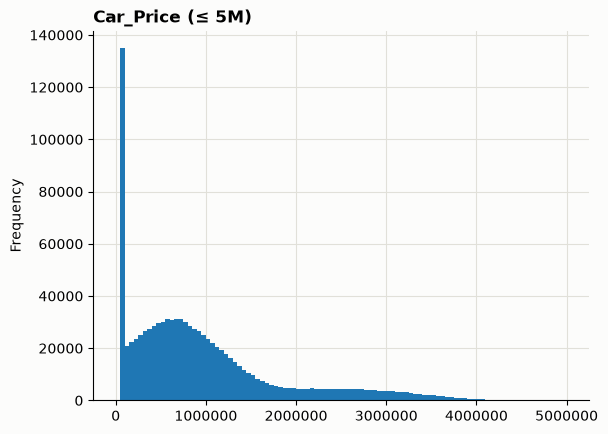

In [48]:
print("Skew Car_Price:", round(df_clean["Car_Price"].skew(), 2))
print("Tỉ lệ xe <= 5M:", round((df_clean["Car_Price"] <= 5_000_000).mean() * 100, 2), "%")

df_clean["Car_Price"].plot(kind="hist", bins=100, range=(0, 5_000_000))
plt.title("Car_Price (≤ 5M)")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

In [49]:
q1, q3 = df_clean["Car_Price"].quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
print("Q1:", round(q1), "| Q3:", round(q3), "| Ngưỡng outlier trên:", round(upper))
print("Số xe > ngưỡng:", (df_clean["Car_Price"] > upper).sum())
print("Trong đó Luxury:", ((df_clean["Car_Price"] > upper) & (df_clean["Segment"] == "Luxury")).sum())

Q1: 340149 | Q3: 1277382 | Ngưỡng outlier trên: 2683231
Số xe > ngưỡng: 67060
Trong đó Luxury: 66847


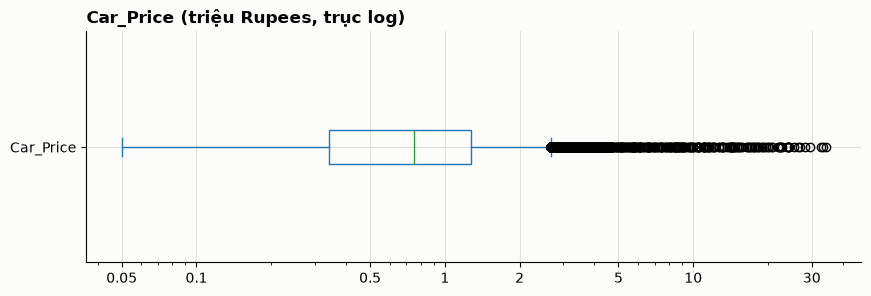

In [50]:
(df_clean["Car_Price"] / 1_000_000).plot(kind="box", vert=False, logx=True, figsize=(10, 3))
plt.xticks([0.05, 0.1, 0.5, 1, 2, 5, 10, 30], ["0.05", "0.1", "0.5", "1", "2", "5", "10", "30"])
plt.title("Car_Price (triệu Rupees, trục log)")
plt.show()

Skew log(Car_Price): -0.78


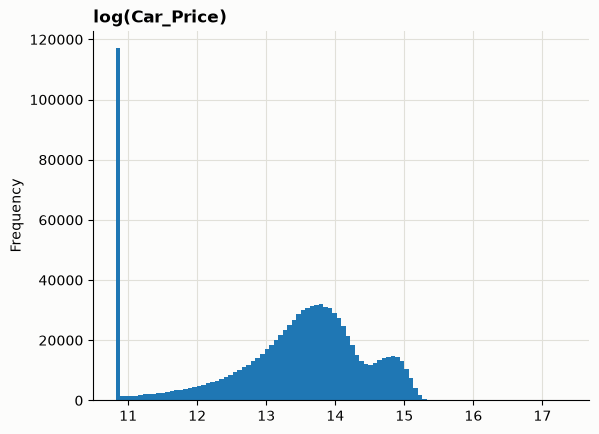

In [51]:
print("Skew log(Car_Price):", round(np.log(df_clean["Car_Price"]).skew(), 2))

np.log(df_clean["Car_Price"]).plot(kind="hist", bins=100)
plt.title("log(Car_Price)")
plt.show()

**Phân phối Car_Price (df_clean)**
- Lệch phải: mean 966,815 > median 753,692, skew 2.06; đuôi dài tới ~34.3M. 99.98% xe ≤ 5M nên histogram chỉ vẽ tới 5M.
- Cột cao nhất tại 50,000 = giá sàn (115,815 xe, ~11.7%).
- Có 2 nhóm giá: đỉnh chính ~0.6–0.7M và một bướu thấp hơn ~2–3.5M (rõ hơn trên log(Car_Price)) → khớp median Non-luxury ~578k và Luxury ~2.14M.
- Boxplot: 50% xe giữa có giá 0.34M–1.28M; ngưỡng outlier trên ≈ 2.68M. 67,060 xe vượt ngưỡng, trong đó 66,847 (99.7%) là Luxury → outlier theo IQR toàn mẫu chủ yếu là xe Luxury hợp lệ, không phải lỗi → nên xét outlier riêng từng segment.
- log(Car_Price): skew -0.78, cân đối hơn nhiều, 2 bướu tách rõ → cân nhắc dùng log(price) cho M2.

In [52]:
df_clean[num_cols].skew().round(2)

Car_Price           2.06
Registration_Age   -0.00
Kms_Driven          0.77
Engine_CC           0.20
Horsepower          0.11
Mileage_kmpl        0.00
Accidents           1.83
dtype: float64

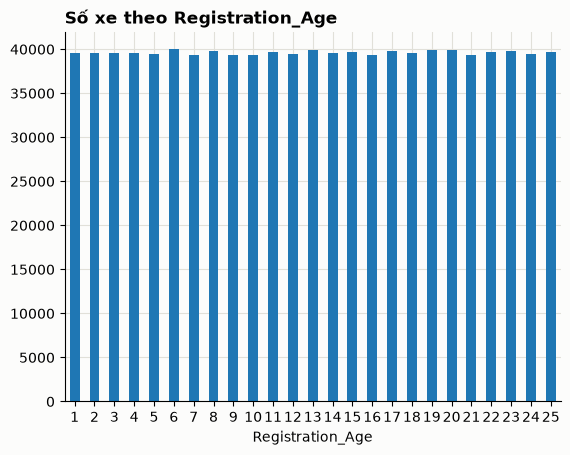

In [53]:
df_clean["Registration_Age"].value_counts().sort_index().plot(kind="bar", rot=0)
plt.title("Số xe theo Registration_Age")
plt.show()

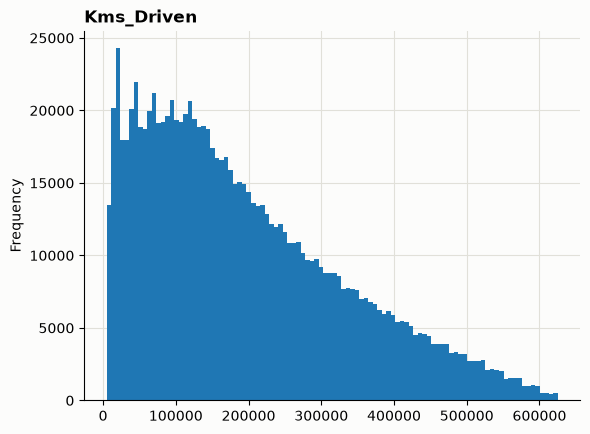

In [54]:
df_clean["Kms_Driven"].plot(kind="hist", bins=100)
plt.title("Kms_Driven")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

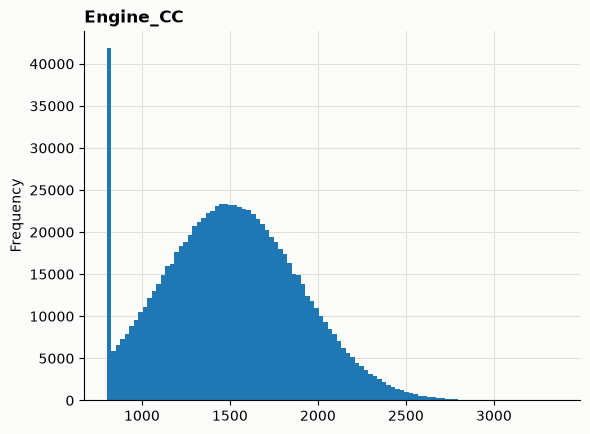

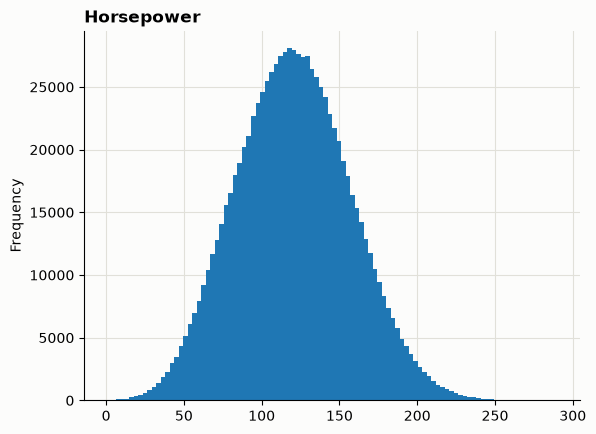

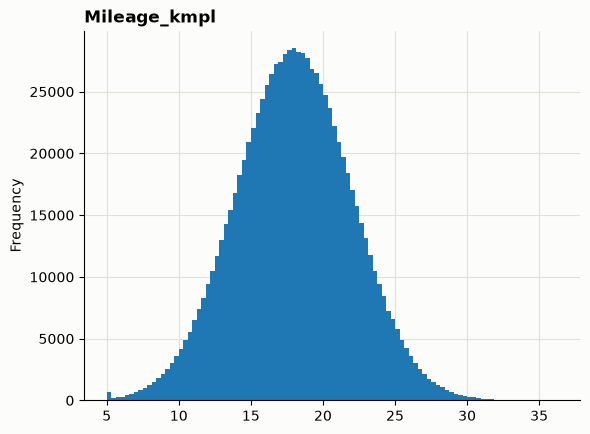

In [55]:
for col in ["Engine_CC", "Horsepower", "Mileage_kmpl"]:
    df_clean[col].plot(kind="hist", bins=100)
    plt.title(col)
    plt.show()

**Phân phối các biến khác (df_clean)**
- Registration_Age: phân bố đều từ 1–25 năm (~40k xe mỗi tuổi) → dữ liệu có dấu hiệu mô phỏng.
- Kms_Driven: lệch phải (skew 0.77, trước khi làm sạch là 4.64), max ~625k; càng nhiều km càng ít xe.
- Engine_CC: gần đối xứng (skew 0.20) nhưng có cột cao tại 800 (giá trị sàn).
- Horsepower, Mileage_kmpl: gần đối xứng (skew 0.11 và 0.00); Mileage có cột nhỏ tại 5.
- Accidents: lệch phải (skew 1.83), median = 0 → đa số xe không có tai nạn.

In [56]:
for col in ["Fuel_Type", "Transmission", "Owner_Type", "Segment"]:
    print(df_clean[col].value_counts(normalize=True).mul(100).round(1))
    print("-" * 30)

Fuel_Type
Petrol      41.2
Diesel      27.7
CNG          9.0
Unknown      7.8
Electric     7.5
Hybrid       6.6
Name: proportion, dtype: float64
------------------------------
Transmission
Manual       59.8
Automatic    32.2
Unknown       8.0
Name: proportion, dtype: float64
------------------------------
Owner_Type
First      59.9
Second     25.0
Third      10.0
Fourth+     5.0
Name: proportion, dtype: float64
------------------------------
Segment
Non-luxury    76.9
Luxury        23.1
Name: proportion, dtype: float64
------------------------------


- Fuel_Type còn 6 nhóm: Petrol 41.2%, Diesel 27.7%, CNG 9.0%, Unknown 7.8%, Electric 7.5%, Hybrid 6.6%.
- Transmission: Manual 59.8%, Automatic 32.2%, Unknown 8.0%. Owner_Type: First 59.9% → Fourth+ 5.0%.
- Segment: Non-luxury 76.9%, Luxury 23.1% (≈ 3/13 hãng, vì mỗi hãng có số xe gần bằng nhau).
- Các nhóm đều ≥ 5% → không còn nhóm hiếm (các nhãn lỗi đã được gộp).

In [57]:
for col in ["Car_Price", "Kms_Driven", "Engine_CC", "Horsepower", "Mileage_kmpl"]:
    s = df_clean[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    n_iqr = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
    n_z = (((s - s.mean()) / s.std()).abs() > 3).sum()
    print(col, "| IQR 1.5x:", n_iqr, "| |z| > 3:", n_z)

Car_Price | IQR 1.5x: 67060 | |z| > 3: 10403
Kms_Driven | IQR 1.5x: 5099 | |z| > 3: 1142
Engine_CC | IQR 1.5x: 3180 | |z| > 3: 1626
Horsepower | IQR 1.5x: 3913 | |z| > 3: 1642
Mileage_kmpl | IQR 1.5x: 6411 | |z| > 3: 2441


In [58]:
for seg in ["Luxury", "Non-luxury"]:
    s = df_clean.loc[df_clean["Segment"] == seg, "Car_Price"]
    q1, q3 = s.quantile([0.25, 0.75])
    upper = q3 + 1.5 * (q3 - q1)
    print(seg, "| ngưỡng trên:", round(upper), "| số xe vượt:", (s > upper).sum(), "| %:", round((s > upper).mean() * 100, 2))

Luxury | ngưỡng trên: 4745650 | số xe vượt: 87 | %: 0.04
Non-luxury | ngưỡng trên: 1950319 | số xe vượt: 432 | %: 0.06


**Outlier sau khi làm sạch**
- IQR (1.5×) gắn cờ nhiều hơn z-score (|z| > 3) ở mọi biến, vd Car_Price 67,060 vs 10,403; Kms_Driven 5,099 vs 1,142.
- Car_Price: 67,060 outlier theo IQR toàn mẫu, 99.7% là xe Luxury (xem boxplot ở trên). Tính ngưỡng riêng từng segment thì chỉ còn 87 xe Luxury (0.04%) và 432 xe Non-luxury (0.06%) → giá cao chủ yếu do segment, không phải lỗi.
- Kms_Driven, Engine_CC, Horsepower, Mileage_kmpl: outlier còn lại là đuôi tự nhiên của phân phối, không vi phạm logic nào (km/năm đều ≤ 25,000).
- → Không xoá thêm dòng nào ở bước này.

In [59]:
corr_cols = ["Registration_Age", "Kms_Driven", "Engine_CC", "Horsepower", "Mileage_kmpl",
             "Accidents", "Service_History", "Insurance_Valid", "Tax_Paid", "Seats", "Number_of_Doors"]
pd.DataFrame({
    "Pearson": df_clean[corr_cols].corrwith(df_clean["Car_Price"]),
    "Spearman": df_clean[corr_cols].corrwith(df_clean["Car_Price"], method="spearman"),
}).round(3)

,Pearson,Spearman
Registration_Age,-0.357,-0.493
Kms_Driven,-0.335,-0.478
Engine_CC,0.046,0.061
Horsepower,0.055,0.072
Mileage_kmpl,-0.000,0.001
Accidents,-0.013,-0.016
Service_History,0.020,0.028
Insurance_Valid,-0.001,0.000
Tax_Paid,-0.001,-0.001
Seats,0.001,0.000


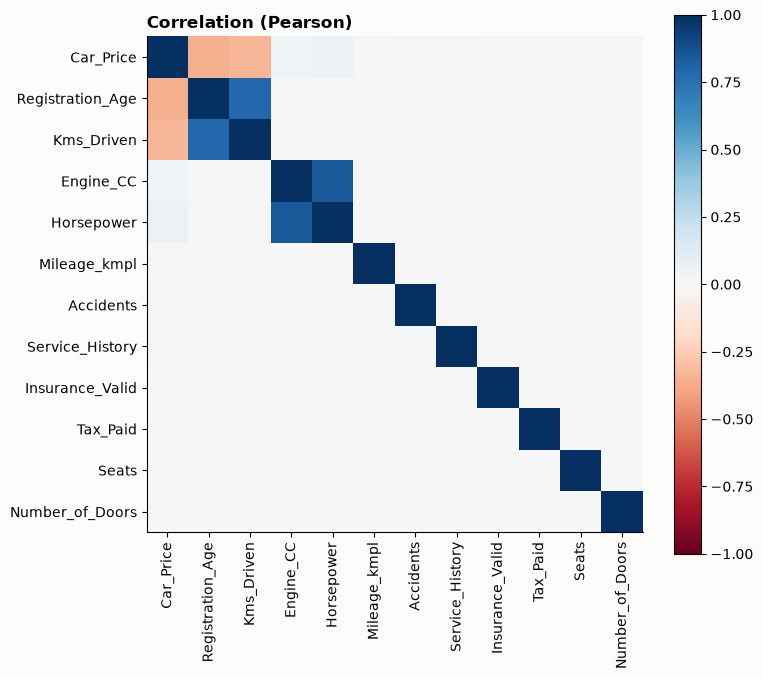

In [60]:
corr = df_clean[["Car_Price"] + corr_cols].corr()
plt.figure(figsize=(8, 7))
plt.imshow(corr, cmap="RdBu", vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar()
plt.grid(False)
plt.title("Correlation (Pearson)")
plt.show()

In [61]:
print("Engine_CC vs Horsepower:", round(df_clean["Engine_CC"].corr(df_clean["Horsepower"]), 3))
print("Registration_Age vs Kms_Driven:", round(df_clean["Registration_Age"].corr(df_clean["Kms_Driven"]), 3))

Engine_CC vs Horsepower: 0.839
Registration_Age vs Kms_Driven: 0.783


**Correlation (df_clean)**
- Với Car_Price: Registration_Age (Pearson -0.357 / Spearman -0.493) và Kms_Driven (-0.335 / -0.478) có quan hệ âm vừa → xe càng cũ, chạy càng nhiều thì càng rẻ.
- Engine_CC, Horsepower, Service_History: rất yếu (|r| ≤ 0.08). Mileage, Accidents, Insurance, Tax, Seats, Doors: ≈ 0.
- Spearman lớn hơn Pearson (về độ lớn) → quan hệ không hoàn toàn tuyến tính (giá lệch phải, có giá sàn).
- Multicollinearity: Engine_CC – Horsepower 0.839; Registration_Age – Kms_Driven 0.783 → không nên đưa cả 2 biến của mỗi cặp vào cùng mô hình mà không cân nhắc. (Year không dùng vì trùng Registration_Age.)
- Correlation toàn mẫu trộn 2 segment có mức giá rất khác nhau → cần xem thêm riêng từng segment (phía dưới).

Số điểm > 6 triệu (không hiện trên hình): 2


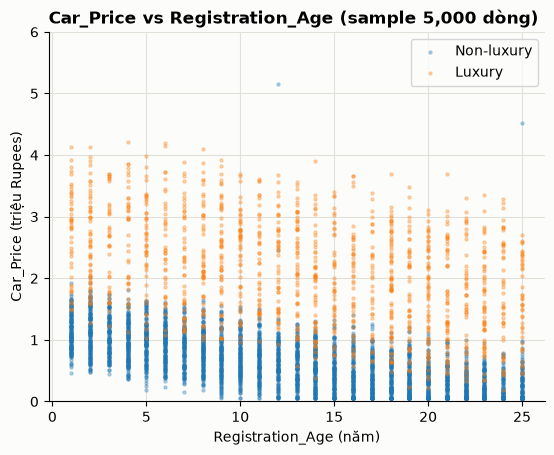

In [62]:
sample = df_clean.sample(5000, random_state=42)
print("Số điểm > 6 triệu (không hiện trên hình):", (sample["Car_Price"] > 6e6).sum())

for seg, color in [("Non-luxury", "tab:blue"), ("Luxury", "tab:orange")]:
    s = sample[sample["Segment"] == seg]
    plt.scatter(s["Registration_Age"], s["Car_Price"] / 1e6, s=5, alpha=0.3, color=color, label=seg)
plt.ylim(0, 6)
plt.title("Car_Price vs Registration_Age (sample 5,000 dòng)")
plt.xlabel("Registration_Age (năm)")
plt.ylabel("Car_Price (triệu Rupees)")
plt.legend()
plt.show()

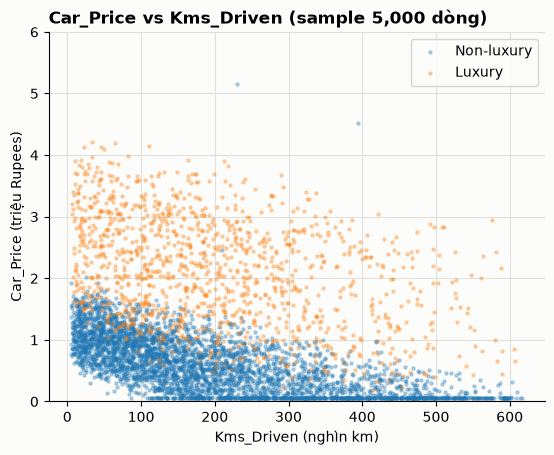

In [63]:
for seg, color in [("Non-luxury", "tab:blue"), ("Luxury", "tab:orange")]:
    s = sample[sample["Segment"] == seg]
    plt.scatter(s["Kms_Driven"] / 1000, s["Car_Price"] / 1e6, s=5, alpha=0.3, color=color, label=seg)
plt.ylim(0, 6)
plt.title("Car_Price vs Kms_Driven (sample 5,000 dòng)")
plt.xlabel("Kms_Driven (nghìn km)")
plt.ylabel("Car_Price (triệu Rupees)")
plt.legend()
plt.show()

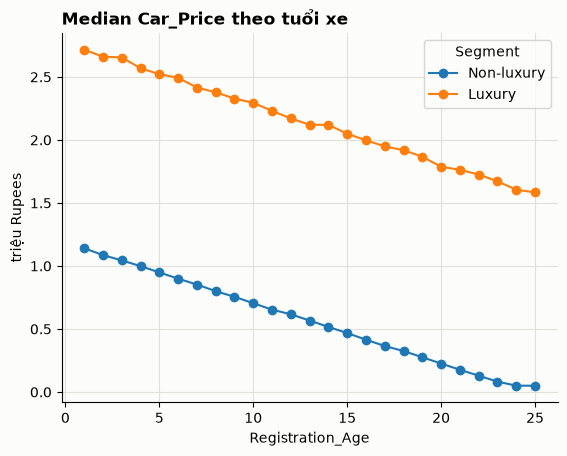

Segment,Non-luxury,Luxury
Registration_Age,,
1,1.14,2.72
5,0.95,2.52
10,0.70,2.29
15,0.47,2.05
20,0.23,1.79
25,0.05,1.58


In [64]:
age_price = df_clean.groupby(["Registration_Age", "Segment"])["Car_Price"].median().unstack()
age_price = age_price[["Non-luxury", "Luxury"]]
(age_price / 1e6).plot(marker="o")
plt.title("Median Car_Price theo tuổi xe")
plt.ylabel("triệu Rupees")
plt.show()

(age_price.loc[[1, 5, 10, 15, 20, 25]] / 1e6).round(2)

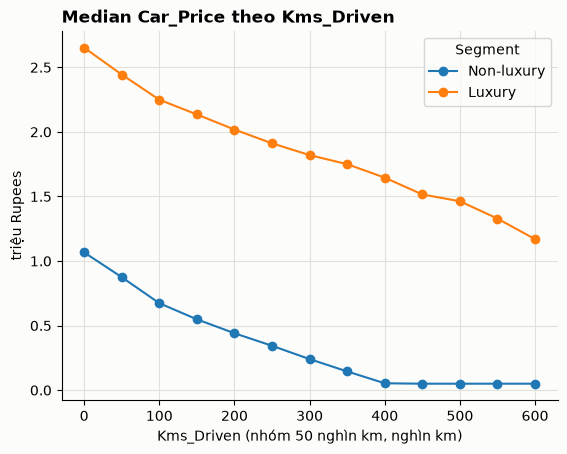

Segment,Non-luxury,Luxury
Kms_Driven,,
0,1.07,2.65
50,0.87,2.44
100,0.67,2.25
150,0.55,2.14
200,0.44,2.02
250,0.34,1.91
300,0.24,1.82
350,0.15,1.75
400,0.05,1.65


In [65]:
kms_band = df_clean["Kms_Driven"] // 50_000 * 50
kms_price = df_clean.groupby([kms_band, "Segment"])["Car_Price"].median().unstack()
kms_price = kms_price[["Non-luxury", "Luxury"]]
(kms_price / 1e6).plot(marker="o")
plt.title("Median Car_Price theo Kms_Driven")
plt.xlabel("Kms_Driven (nhóm 50 nghìn km, nghìn km)")
plt.ylabel("triệu Rupees")
plt.show()

(kms_price / 1e6).round(2)

**Giá theo tuổi xe và Kms_Driven (câu hỏi 1 của Guide)**
- Cách làm: vẽ ~1 triệu điểm thì không đọc được → scatter trên sample ngẫu nhiên 5,000 dòng (random_state=42), kèm median theo nhóm tính trên toàn bộ df_clean. Trục y cắt ở 6 triệu (ẩn 2 điểm).
- Scatter: 2 dải giá tách biệt theo segment; giá giảm dần theo tuổi xe và theo Kms ở cả 2 segment; ở xe cũ / chạy nhiều có nhiều điểm Non-luxury nằm sát đáy (giá sàn 0.05M).
- Median theo tuổi: Luxury 2.72M (1 năm) → 2.29M (10 năm) → 1.58M (25 năm); Non-luxury 1.14M → 0.70M → 0.05M (chạm giá sàn). 2 đường giảm gần như thẳng.
- Median theo Kms: Luxury 2.65M (< 50k km) → 1.17M (≥ 600k km); Non-luxury 1.07M → chạm giá sàn 0.05M từ khoảng 400k km trở lên.
- Kms và tuổi xe tương quan mạnh (0.783) → xu hướng theo Kms phần lớn trùng với xu hướng theo tuổi.

In [66]:
for col in ["Fuel_Type", "Transmission", "Owner_Type"]:
    print(pd.crosstab(df_clean["Segment"], df_clean[col], normalize="index").mul(100).round(1))
    print("-" * 30)

Fuel_Type   CNG  Diesel  Electric  Hybrid  Petrol  Unknown
Segment                                                   
Luxury      9.0    27.8       7.5     6.7    41.2      7.9
Non-luxury  9.0    27.7       7.6     6.6    41.2      7.8
------------------------------
Transmission  Automatic  Manual  Unknown
Segment                                 
Luxury             32.2    59.7      8.1
Non-luxury         32.2    59.8      8.0
------------------------------
Owner_Type  First  Fourth+  Second  Third
Segment                                  
Luxury       59.9      5.1    25.0   10.0
Non-luxury   59.9      5.0    25.1   10.0
------------------------------


- Cơ cấu Fuel_Type, Transmission, Owner_Type gần như giống hệt nhau giữa 2 segment (chênh ≤ 0.1 điểm %), vd Petrol 41.2% ở cả 2 nhóm, Manual 59.7% vs 59.8%.
- → Chênh lệch giá giữa Luxury và Non-luxury không đến từ khác biệt về nhiên liệu, hộp số hay số đời chủ.

In [67]:
for col in ["Fuel_Type", "Transmission", "Owner_Type", "Color", "City", "Accidents",
            "Service_History", "Insurance_Valid", "Tax_Paid", "Seats", "Number_of_Doors"]:
    m = df_clean.groupby(col)["Car_Price"].median()
    print(col, ":", round(m.min()), "->", round(m.max()), "| max/min =", round(m.max() / m.min(), 2))

Fuel_Type : 749072 -> 757843 | max/min = 1.01
Transmission : 753242 -> 755438 | max/min = 1.0
Owner_Type : 752666 -> 755394 | max/min = 1.0
Color : 748577 -> 756497 | max/min = 1.01
City : 750337 -> 756557 | max/min = 1.01
Accidents : 473157 -> 760271 | max/min = 1.61
Service_History : 718426 -> 765187 | max/min = 1.07
Insurance_Valid : 752552 -> 753974 | max/min = 1.0


Tax_Paid : 753534 -> 754999 | max/min = 1.0
Seats : 753161 -> 755456 | max/min = 1.0
Number_of_Doors : 753321 -> 757763 | max/min = 1.01


In [68]:
print(pd.crosstab(df_clean["Accidents"], df_clean["Segment"]))
df_clean.groupby(["Accidents", "Segment"])["Car_Price"].median().unstack().round()

Segment    Luxury  Non-luxury
Accidents                    
0          169398      564909
1           50985      168617
2            7656       25279
3             731        2617
4              54         166
5               3          12


Segment,Luxury,Non-luxury
Accidents,,
0,2150955.0,584421.0
1,2126695.0,561526.0
2,2102019.0,537234.0
3,2113834.0,495896.0
4,2000099.0,543744.0
5,2658703.0,267221.0


In [69]:
df_clean.groupby(["Service_History", "Segment"])["Car_Price"].median().unstack().round()

Segment,Luxury,Non-luxury
Service_History,,
0,2108954.0,540971.0
1,2155802.0,589862.0


**Giá theo các biến khác**
- Fuel_Type, Transmission, Owner_Type, Color, City, Insurance_Valid, Tax_Paid, Seats, Number_of_Doors: median giữa các nhóm chênh ≤ 1% (max/min ≤ 1.01) → gần như không ảnh hưởng tới giá.
- Accidents: median giảm dần theo số tai nạn: Luxury 2.15M (0) → 2.13M (1) → 2.10M (2); Non-luxury 584k → 562k → 537k → mỗi vụ giảm ~23–24k ở cả 2 segment. Nhóm 3–5 vụ có ít xe (vd 5 vụ: 3 Luxury, 12 Non-luxury) → median không ổn định (max/min = 1.61 là do nhóm này).
- Service_History: có hồ sơ bảo dưỡng thì median cao hơn ~47–49k ở cả 2 segment (Luxury +2.2%, Non-luxury +9.0%).
- → Các biến đáng chú ý cho M2: Registration_Age, Kms_Driven, Segment / Brand, Accidents, Service_History.

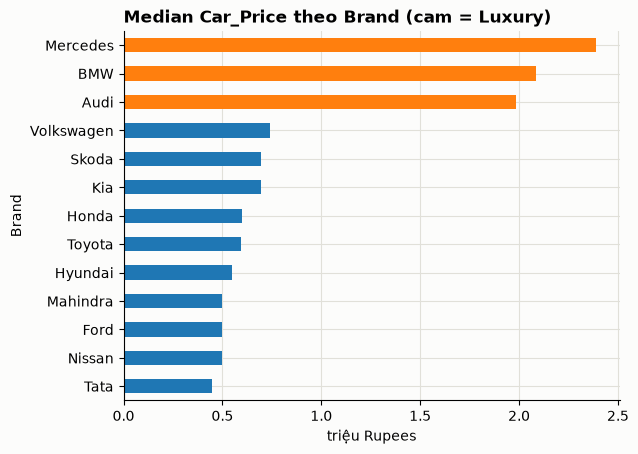

Brand
Mercedes      2.39
BMW           2.09
Audi          1.98
Volkswagen    0.74
Skoda         0.70
Kia           0.69
Honda         0.60
Toyota        0.59
Hyundai       0.55
Nissan        0.50
Ford          0.50
Mahindra      0.50
Tata          0.45
Name: Car_Price, dtype: float64

In [70]:
brand_price = df_clean.groupby("Brand")["Car_Price"].median().sort_values()
colors = ["tab:orange" if b in lux else "tab:blue" for b in brand_price.index]
(brand_price / 1e6).plot(kind="barh", color=colors)
plt.title("Median Car_Price theo Brand (cam = Luxury)")
plt.xlabel("triệu Rupees")
plt.show()

(brand_price / 1e6).round(2).sort_values(ascending=False)

In [71]:
model_price = df_clean.groupby(["Brand", "Model"])["Car_Price"].median()
(model_price.groupby("Brand").max() / model_price.groupby("Brand").min()).round(3).sort_values()

Brand
Toyota        1.002
BMW           1.005
Ford          1.005
Skoda         1.006
Audi          1.007
Hyundai       1.007
Kia           1.007
Mahindra      1.009
Nissan        1.010
Honda         1.012
Mercedes      1.015
Tata          1.021
Volkswagen    1.028
Name: Car_Price, dtype: float64

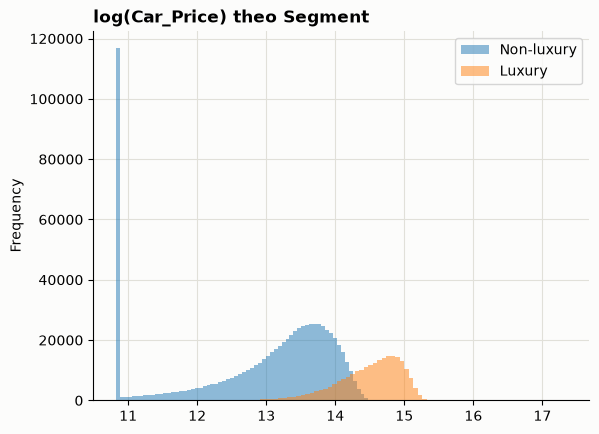

In [72]:
for seg in ["Non-luxury", "Luxury"]:
    np.log(df_clean.loc[df_clean["Segment"] == seg, "Car_Price"]).plot(kind="hist", bins=100, alpha=0.5, label=seg)
plt.title("log(Car_Price) theo Segment")
plt.legend()
plt.show()

In [73]:
df_clean.groupby("Segment")["Car_Price"].describe().round()

,count,mean,std,min,25%,50%,75%,max
Segment,,,,,,,,
Luxury,228827.0,2158609.0,903717.0,50000.0,1499803.0,2143656.0,2798142.0,34305030.0
Non-luxury,761600.0,608734.0,440222.0,50000.0,228094.0,577725.0,916984.0,15240344.0


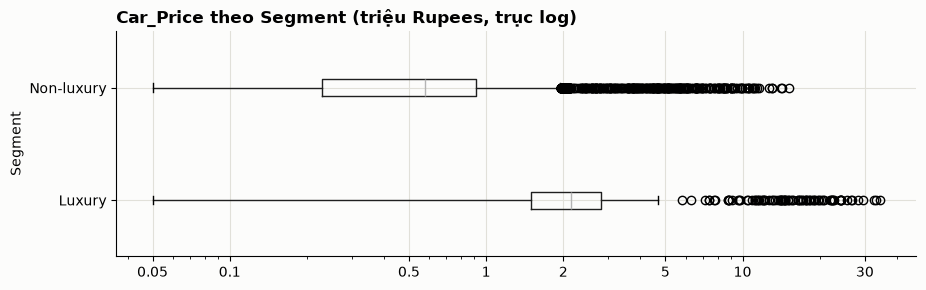

In [74]:
df_clean.boxplot(column="Car_Price", by="Segment", vert=False, figsize=(10, 3))
plt.xscale("log")
plt.xticks([5e4, 1e5, 5e5, 1e6, 2e6, 5e6, 1e7, 3e7], ["0.05", "0.1", "0.5", "1", "2", "5", "10", "30"])
plt.suptitle("")
plt.title("Car_Price theo Segment (triệu Rupees, trục log)")
plt.show()

**Ảnh hưởng của Segment (câu hỏi 2 của Guide)**
- Median theo Brand: 3 hãng Luxury 1.98–2.39M (Mercedes cao nhất), 10 hãng Non-luxury 0.45–0.74M (Tata thấp nhất, Volkswagen cao nhất) → 2 nhóm tách hẳn nhau.
- Trong cùng 1 Brand, median giữa các Model chênh ≤ 2.8% (Volkswagen 1.028) → Model gần như không thêm thông tin ngoài Brand.
- log(Car_Price): 2 bướu trong phân phối giá chính là 2 segment; Non-luxury có thêm cột giá sàn.
- Luxury: Q1–Q3 = 1.50M–2.80M, median 2.14M; Non-luxury: Q1–Q3 = 0.23M–0.92M, median 0.58M → 2 hộp không chồng nhau, median gấp ~3.7 lần.
- Non-luxury vẫn còn vài xe giá rất cao (tới ~15M, 432 xe > 1.95M) → số lượng nhỏ, giữ lại nhưng lưu ý.

In [75]:
for seg in ["Luxury", "Non-luxury"]:
    d = df_clean[df_clean["Segment"] == seg]
    print(seg, "| corr(giá, tuổi):", round(d["Car_Price"].corr(d["Registration_Age"]), 3),
          "| corr(giá, km):", round(d["Car_Price"].corr(d["Kms_Driven"]), 3))

Luxury | corr(giá, tuổi): -0.383 | corr(giá, km): -0.368
Non-luxury | corr(giá, tuổi): -0.689 | corr(giá, km): -0.638


In [76]:
print("Median giảm trung bình mỗi năm (tuổi 1 -> 20):")
print(((age_price.loc[1] - age_price.loc[20]) / 19).round())
print("Median ở tuổi 20 so với tuổi 1 (%):")
print((age_price.loc[20] / age_price.loc[1] * 100).round(1))

Median giảm trung bình mỗi năm (tuổi 1 -> 20):
Segment
Non-luxury    48159.0
Luxury        48910.0
dtype: float64
Median ở tuổi 20 so với tuổi 1 (%):
Segment
Non-luxury    19.8
Luxury        65.8
dtype: float64


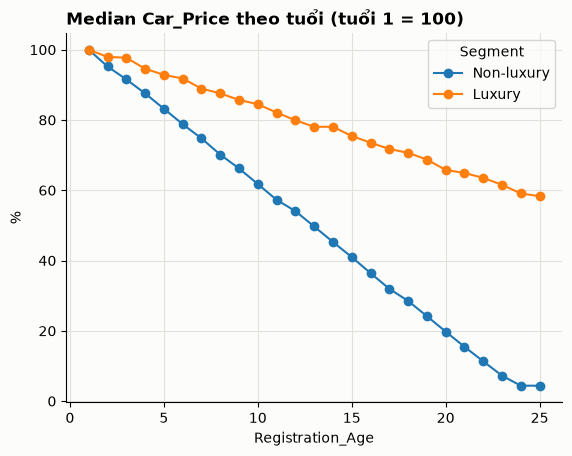

In [77]:
(age_price / age_price.loc[1] * 100).plot(marker="o")
plt.title("Median Car_Price theo tuổi (tuổi 1 = 100)")
plt.ylabel("%")
plt.show()

**Giá theo tuổi trong từng segment (gợi ý interaction cho M2)**
- Correlation giá – tuổi: Luxury -0.383, Non-luxury -0.689; giá – km: -0.368 vs -0.638 → quan hệ mạnh hơn ở Non-luxury.
- Theo Rupees: từ tuổi 1 → 20, median giảm trung bình ~48.9k/năm (Luxury) và ~48.2k/năm (Non-luxury) → gần như bằng nhau, 2 đường median gần song song.
- Theo %: ở tuổi 20, Luxury còn 65.8% giá của xe 1 năm, Non-luxury chỉ còn 19.8% → Non-luxury mất giá nhanh hơn nhiều tính theo %.
- → Có interaction Segment × tuổi hay không phụ thuộc vào thang đo (Rupees hay %/log) → cần kiểm định ở M2 trên cả price và log(price).

In [78]:
df_clean.groupby("City")["Car_Price"].agg(["count", "median"]).round()

,count,median
City,,
Ahmedabad,113817,753948.0
Bangalore,113751,751258.0
Chennai,113366,753472.0
Delhi,114291,756164.0
Hyderabad,114162,754092.0
Kolkata,113781,752119.0
Mumbai,114082,756557.0
Pune,113931,750337.0
Unknown,79246,755823.0


In [79]:
pd.crosstab(df_clean["City"], df_clean["Segment"], normalize="index").mul(100).round(1)

Segment,Luxury,Non-luxury
City,,
Ahmedabad,23.2,76.8
Bangalore,23.1,76.9
Chennai,23.1,76.9
Delhi,23.1,76.9
Hyderabad,23.0,77.0
Kolkata,23.1,76.9
Mumbai,23.2,76.8
Pune,23.0,77.0
Unknown,23.2,76.8


**City và tính đại diện của mẫu**
- Median giá giữa 8 city chỉ chênh ~0.8% (750k – 757k); nhóm City = Unknown cũng tương tự (756k) → City gần như không ảnh hưởng tới giá.
- Tỉ lệ Luxury ở mọi city ~23.0–23.2% → segment phân bố đều theo city.
- Mỗi city có ~113–114k xe (Unknown ~79k) → mẫu được chia đều theo city (và theo brand, theo năm) → không phản ánh quy mô thị trường thật, cần nêu khi khái quát hoá.

**Tổng kết EDA**

**Phát hiện chính**
1. Car_Price lệch phải (mean 966,815 > median 753,692, skew 2.06) → báo cáo median cho khách hàng; cân nhắc log(price) khi phân tích.
2. Segment quyết định mức giá: median Luxury 2.14M vs Non-luxury 0.58M (gấp ~3.7 lần). 2 nhóm có cùng "hồ sơ xe" (tuổi, km, nhiên liệu, hộp số… gần như giống hệt).
3. Giá giảm theo tuổi xe (Spearman -0.49) và theo Kms (-0.48). Theo Rupees, median giảm ~48–49k/năm ở cả 2 segment; theo %, Non-luxury giảm nhanh hơn nhiều (ở tuổi 20 còn 19.8% vs 65.8%).
4. Kms – tuổi xe tương quan 0.78, Engine_CC – Horsepower 0.84 → lưu ý multicollinearity.
5. Accidents (~ -23k/vụ) và Service_History (~ +48k) có ảnh hưởng nhỏ; Fuel, Transmission, Owner, Color, City, Seats, Doors, Insurance, Tax gần như không ảnh hưởng (median chênh ≤ 1%).
6. Lỗi dữ liệu đã xử lý: nhãn không thống nhất (Brand, Fuel_Type), 5,000 dòng trùng, 32 Horsepower ≤ 0, 9,623 dòng Kms phi lý. Giữ lại: 'Unknown' (~28% dòng) và missing (~22% dòng) vì ngẫu nhiên, giá sàn 50,000 (~11.7%) vì xoá sẽ làm lệch mẫu.

**Hypothesis gợi ý cho M2**
- H1: Mean Car_Price của Luxury cao hơn Non-luxury.
- H2: Car_Price có quan hệ âm với Registration_Age (trong từng segment).
- H3: Tốc độ mất giá theo tuổi khác nhau giữa 2 segment (interaction) — kiểm định trên cả price và log(price).
- H4: Kms_Driven vẫn giải thích thêm được giá sau khi đã tính tới tuổi xe.
- H5: Xe có Service_History / ít tai nạn có giá cao hơn.

**Hạn chế (cho Objective 2)**
- Giá bị chặn sàn ở 50,000 → không biết giá thật của những xe rẻ nhất.
- Mẫu chia đều theo brand, city, năm sản xuất → không phản ánh cơ cấu thị trường thật.
- Không có ngày đăng tin → không phân tích được xu hướng theo thời gian; chỉ có 13 brand, 39 model, 8 city.
- Nhiều biến gần như không liên quan tới giá → dữ liệu có dấu hiệu mô phỏng.

**Cần quyết định**
- Ngưỡng Kms phi lý: km/năm > 25,000 (đang dùng) hay Kms > 1,000,000 (theo Guide).
- Giữ hay xoá giá sàn (đang giữ + đánh dấu `is_floor`).
- Dùng price hay log(price) cho M2.
- Chọn biến: Registration_Age (không dùng Year), 1 trong Engine_CC / Horsepower, Segment hay Brand.